# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [10]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

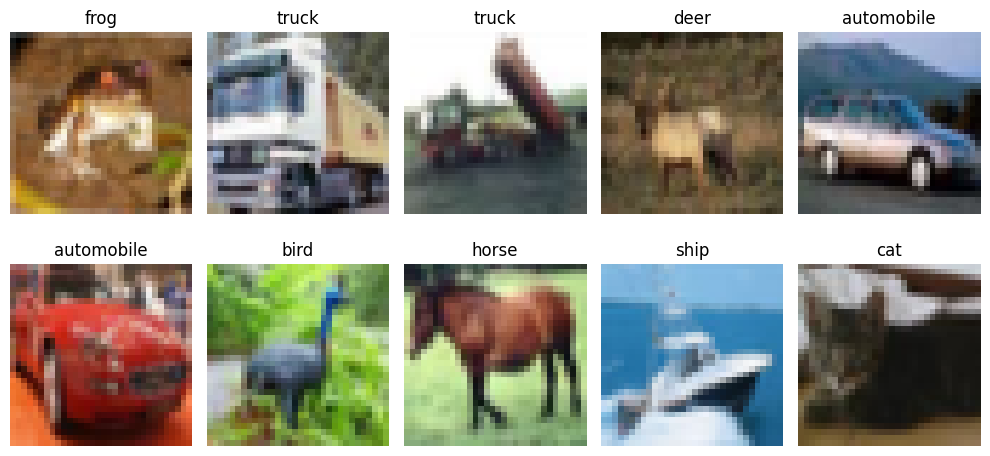

In [11]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [12]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [13]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\Harsh\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2673 - loss: 2.0003 - val_accuracy: 0.3360 - val_loss: 1.8842
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3152 - loss: 1.8724 - val_accuracy: 0.3276 - val_loss: 1.8307
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3368 - loss: 1.8166 - val_accuracy: 0.3828 - val_loss: 1.7346
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3507 - loss: 1.7814 - val_accuracy: 0.3718 - val_loss: 1.7549
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3587 - loss: 1.7648 - val_accuracy: 0.4124 - val_loss: 1.6908
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3700 - loss: 1.7358 - val_accuracy: 0.4000 - val_loss: 1.7143
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3731 - loss: 1.7234 - val_accuracy: 0.4026 - val_loss: 1.6599
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3807 - loss: 1.7076 - val_accuracy: 0.

In [14]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4244 - loss: 1.6462
ANN Test Accuracy: 0.4244000017642975


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [15]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\Harsh\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.4725 - loss: 1.4874 - val_accuracy: 0.3866 - val_loss: 1.9724
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6062 - loss: 1.1213 - val_accuracy: 0.5728 - val_loss: 1.2237
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6704 - loss: 0.9452 - val_accuracy: 0.6866 - val_loss: 0.9142
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7119 - loss: 0.8279 - val_accuracy: 0.6504 - val_loss: 0.9766
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7447 - loss: 0.7274 - val_accuracy: 0.6998 - val_loss: 0.8800
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7708 - loss: 0.6512 - val_accuracy: 0.6936 - val_loss: 0.9165
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7986 - loss: 0.5758 - val_accuracy: 0.7384 - val_loss: 0.8206
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8163 - loss: 0.5172 - 

In [16]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6813 - loss: 1.2153
CNN Test Accuracy: 0.6812999844551086


## 📈 Compare Learning Curves

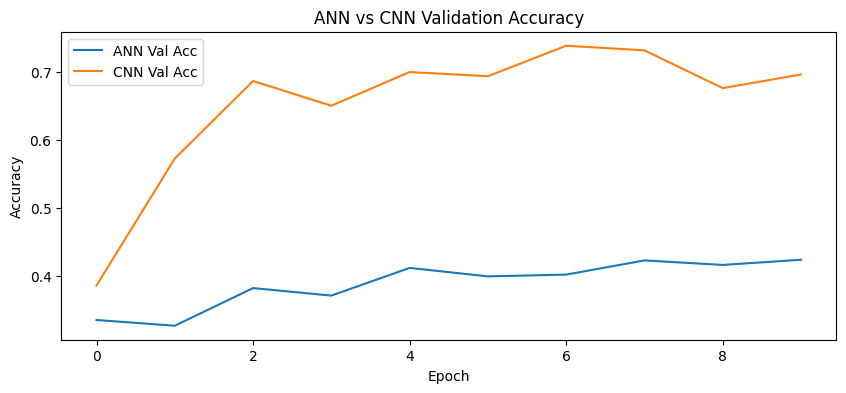

In [17]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3560 - loss: 1.7557 - val_accuracy: 0.4838 - val_loss: 1.4116
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4532 - loss: 1.5141 - val_accuracy: 0.5094 - val_loss: 1.3903
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4900 - loss: 1.4224 - val_accuracy: 0.5584 - val_loss: 1.2484
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5143 - loss: 1.3637 - val_accuracy: 0.5866 - val_loss: 1.1654
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5334 - loss: 1.3082 - val_accuracy: 0.5740 - val_loss: 1.2232
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5482 - loss: 1.2729 - val_accuracy: 0.6124 - val_loss: 1.1012
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5564 - loss: 1.2524 - val_accuracy: 0.6184 - val_loss: 1.0814
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5694 - loss: 1.2211 - val

# 📊 Final Comparison Table

In [19]:
comparison = pd.DataFrame({
    "Model":         ["ANN (Baseline)", "CNN (Baseline)", "CNN + Augmentation"],
    "Test Accuracy": [round(ann_test_acc, 4), round(cnn_test_acc, 4), round(aug_test_acc, 4)],
    "Architecture":  ["Dense 512→256→10", "Conv2D×3 + BN + Dense", "Augmentation + Conv2D×2 + Dense"],
    "Epochs":        [10, 10, 10]
})
comparison

,Model,Test Accuracy,Architecture,Epochs
0,ANN (Baseline),0.4244,Dense 512→256→10,10
1,CNN (Baseline),0.6813,Conv2D×3 + BN + Dense,10
2,CNN + Augmentation,0.6320,Augmentation + Conv2D×2 + Dense,10


# 🎓 Student Learning Tasks — Completed Implementations

All 5 beginner tasks are implemented and runnable below.

## ✅ Task 1 — Increase ANN Layers and Observe Performance

We add two extra Dense layers (128 and 64 neurons) to the original ANN and compare results.
More layers can help learn more complex representations, but also risk overfitting.

C:\Users\Harsh\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,506 (6.66 MB)

 Trainable params: 1,746,506 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2081 - loss: 2.0996 - val_accuracy: 0.2968 - val_loss: 1.9401
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2790 - loss: 1.9433 - val_accuracy: 0.3350 - val_loss: 1.8635
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3033 - loss: 1.8980 - val_accuracy: 0.3406 - val_loss: 1.8374
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3137 - loss: 1.8695 - val_accuracy: 0.3500 - val_loss: 1.8261
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3219 - loss: 1.8465 - val_accuracy: 0.3634 - val_loss: 1.7873
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3361 - loss: 1.8179 - val_accuracy: 0.3514 - val_loss: 1.7860
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3368 - loss: 1.8109 - val_accuracy: 0.3696 - val_loss: 1.7494
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3465 - loss: 1.7949 - val_accuracy: 0

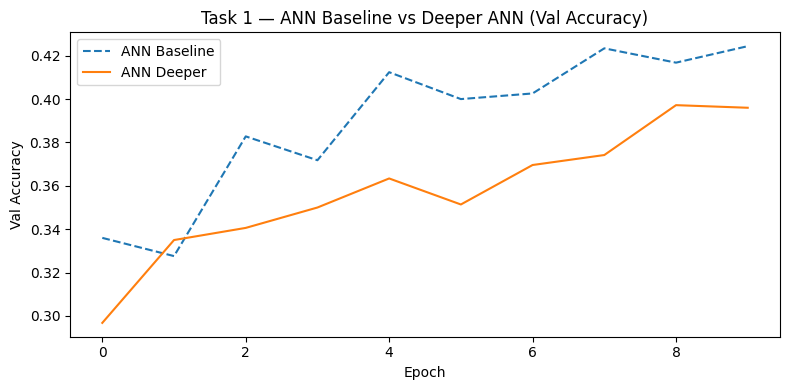

In [20]:
# Task 1: Deeper ANN with more layers
ann_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),   # NEW
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),    # NEW
    layers.Dense(10, activation='softmax')
])

ann_deep.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

ann_deep.summary()

ann_deep_history = ann_deep.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

_, ann_deep_acc = ann_deep.evaluate(x_test_flat, y_test)
print(f"\nBaseline ANN Test Accuracy : {ann_test_acc:.4f}")
print(f"Deeper   ANN Test Accuracy : {ann_deep_acc:.4f}")
print(f"Improvement: {(ann_deep_acc - ann_test_acc)*100:+.2f}%")

# Plot
plt.figure(figsize=(8,4))
plt.plot(ann_history.history['val_accuracy'],      label='ANN Baseline', linestyle='--')
plt.plot(ann_deep_history.history['val_accuracy'], label='ANN Deeper',   linestyle='-')
plt.title("Task 1 — ANN Baseline vs Deeper ANN (Val Accuracy)")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

## ✅ Task 2 — Scale CNN Filters: 32 → 64 → 128

Increasing filter depth lets the network learn richer feature hierarchies.
Early layers (32 filters) detect edges; deeper layers (128 filters) capture object parts.

C:\Users\Harsh\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,194,122 (8.37 MB)

 Trainable params: 2,193,674 (8.37 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.4830 - loss: 1.4706 - val_accuracy: 0.5814 - val_loss: 1.2162
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.6362 - loss: 1.0440 - val_accuracy: 0.5624 - val_loss: 1.3928
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.7032 - loss: 0.8470 - val_accuracy: 0.6870 - val_loss: 0.8976
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7537 - loss: 0.7007 - val_accuracy: 0.6718 - val_loss: 0.9841
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7940 - loss: 0.5911 - val_accuracy: 0.6872 - val_loss: 0.9928
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.8253 - loss: 0.4932 - val_accuracy: 0.6702 - val_loss: 1.0269
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.8584 - loss: 0.4053 - val_accuracy: 0.7290 - val_loss: 0.9090
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.8761 - loss: 0.3541 - 

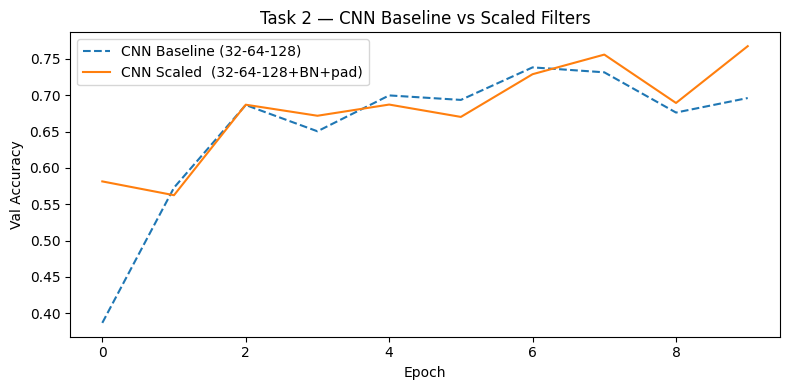

In [21]:
# Task 2: CNN with scaled-up filters 32 → 64 → 128
cnn_scaled = models.Sequential([
    layers.Conv2D(32,  (3,3), activation='relu', input_shape=(32,32,3), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_scaled.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

cnn_scaled.summary()

cnn_scaled_history = cnn_scaled.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

_, cnn_scaled_acc = cnn_scaled.evaluate(x_test_norm, y_test)
print(f"\nBaseline CNN Test Accuracy : {cnn_test_acc:.4f}")
print(f"Scaled   CNN Test Accuracy : {cnn_scaled_acc:.4f}")
print(f"Improvement: {(cnn_scaled_acc - cnn_test_acc)*100:+.2f}%")

plt.figure(figsize=(8,4))
plt.plot(cnn_history.history['val_accuracy'],       label='CNN Baseline (32-64-128)', linestyle='--')
plt.plot(cnn_scaled_history.history['val_accuracy'],label='CNN Scaled  (32-64-128+BN+pad)', linestyle='-')
plt.title("Task 2 — CNN Baseline vs Scaled Filters")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

## ✅ Task 3 — Increase Training to 20 Epochs

Training for more epochs allows both models to converge further.
We observe whether accuracy improves or if overfitting kicks in.

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.4721 - loss: 1.4755 - val_accuracy: 0.5504 - val_loss: 1.2873
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.6145 - loss: 1.1053 - val_accuracy: 0.6206 - val_loss: 1.0673
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6763 - loss: 0.9313 - val_accuracy: 0.6636 - val_loss: 0.9766
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7148 - loss: 0.8175 - val_accuracy: 0.6966 - val_loss: 0.8840
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.7494 - loss: 0.7155 - val_accuracy: 0.6598 - val_loss: 1.1714
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7748 - loss: 0.6375 - val_accuracy: 0.7170 - val_loss: 0.8428
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7972 - loss: 0.5737 - val_accuracy: 0.7076 - val_loss: 0.9545
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8182 - loss: 0.5170 - 

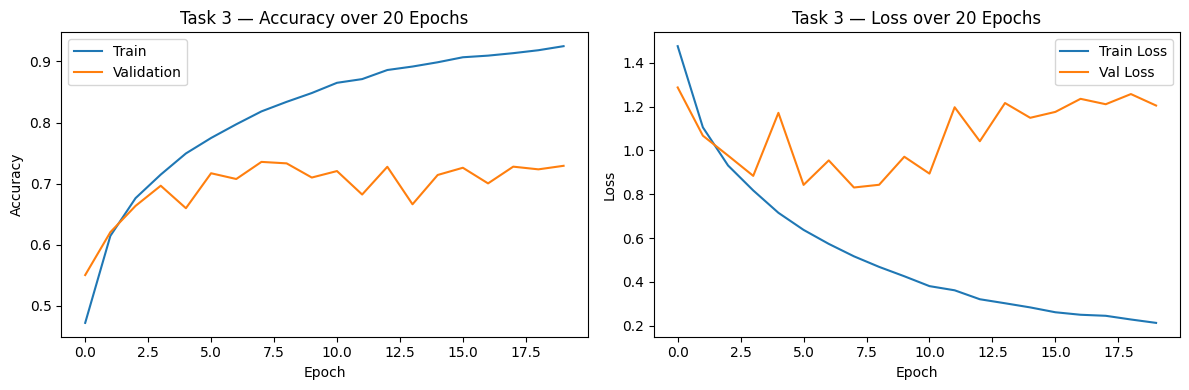

In [22]:
# Task 3: Train CNN for 20 epochs
cnn_20ep = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20ep.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

cnn_20ep_history = cnn_20ep.fit(
    x_train_norm, y_train,
    epochs=20,           # ← increased from 10
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

_, cnn_20ep_acc = cnn_20ep.evaluate(x_test_norm, y_test)
print(f"\n10-epoch CNN Test Accuracy : {cnn_test_acc:.4f}")
print(f"20-epoch CNN Test Accuracy : {cnn_20ep_acc:.4f}")
print(f"Improvement: {(cnn_20ep_acc - cnn_test_acc)*100:+.2f}%")

# Plot train vs val accuracy to check overfitting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_20ep_history.history['accuracy'],     label='Train')
axes[0].plot(cnn_20ep_history.history['val_accuracy'], label='Validation')
axes[0].set_title("Task 3 — Accuracy over 20 Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(cnn_20ep_history.history['loss'],     label='Train Loss')
axes[1].plot(cnn_20ep_history.history['val_loss'], label='Val Loss')
axes[1].set_title("Task 3 — Loss over 20 Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout(); plt.show()

## ✅ Task 4 — Add EarlyStopping

EarlyStopping monitors validation loss and stops training when it stops improving,
preventing overfitting and saving compute time. `restore_best_weights=True` ensures
we keep the best model checkpoint automatically.

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.4634 - loss: 1.4978 - val_accuracy: 0.5766 - val_loss: 1.1693 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6143 - loss: 1.1175 - val_accuracy: 0.6354 - val_loss: 1.0556 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6733 - loss: 0.9461 - val_accuracy: 0.6226 - val_loss: 1.1118 - learning_rate: 0.0010
Epoch 4/50
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7129 - loss: 0.8302
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7100 - loss: 0.8343 - val_accuracy: 0.6576 - val_loss: 1.0575 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7731 - loss: 0.6489 - val_accuracy: 0.7434 - val_loss: 0.7671 - learning_rate: 5.0000e-04
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7979 -

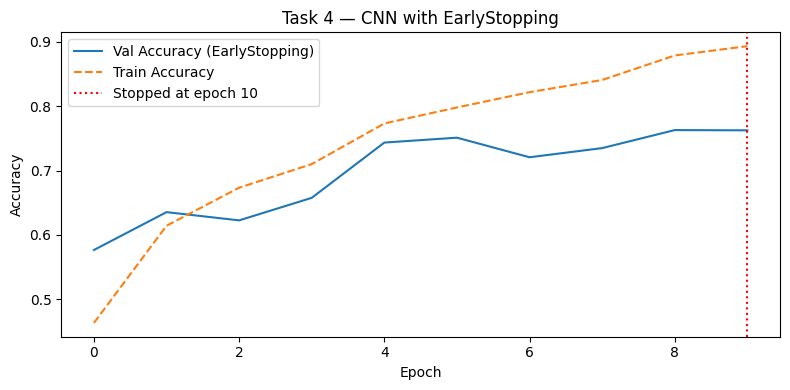

In [23]:
# Task 4: CNN with EarlyStopping callback
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,              # stop if val_loss doesn't improve for 4 consecutive epochs
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

cnn_early = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_early.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_early_history = cnn_early.fit(
    x_train_norm, y_train,
    epochs=50,              # high ceiling — EarlyStopping will halt it
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

_, cnn_early_acc = cnn_early.evaluate(x_test_norm, y_test)
actual_epochs = len(cnn_early_history.history['val_loss'])
print(f"\nTraining stopped at epoch: {actual_epochs}")
print(f"EarlyStopping CNN Test Accuracy: {cnn_early_acc:.4f}")

plt.figure(figsize=(8,4))
plt.plot(cnn_early_history.history['val_accuracy'], label='Val Accuracy (EarlyStopping)')
plt.plot(cnn_early_history.history['accuracy'],     label='Train Accuracy', linestyle='--')
plt.axvline(actual_epochs - 1, color='red', linestyle=':', label=f'Stopped at epoch {actual_epochs}')
plt.title("Task 4 — CNN with EarlyStopping")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

## ✅ Task 5 — Run Augmented CNN Training (Full 20 Epochs + EarlyStopping)

Data augmentation artificially expands the training set by applying random transformations
(flips, rotations, zooms) at training time. This forces the model to learn features that
are invariant to these transformations, significantly improving generalization on unseen data.

Model: "Augmented_CNN_Full"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.3657 - loss: 1.7871 - val_accuracy: 0.5058 - val_loss: 1.3574
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.4716 - loss: 1.4746 - val_accuracy: 0.4692 - val_loss: 1.5715
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5274 - loss: 1.3341 - val_accuracy: 0.6050 - val_loss: 1.2028
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.5644 - loss: 1.2492 - val_accuracy: 0.5286 - val_loss: 1.5109
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.5890 - loss: 1.1770 - val_accuracy: 0.6194 - val_loss: 1.2089
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.6121 - loss: 1.1216 - val_accuracy: 0.5786 - val_loss: 1.2871
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.6262 - loss: 1.0819 - val_accuracy: 0.6924 - val_loss: 0.8910
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.6402 - loss: 1.0386 - 

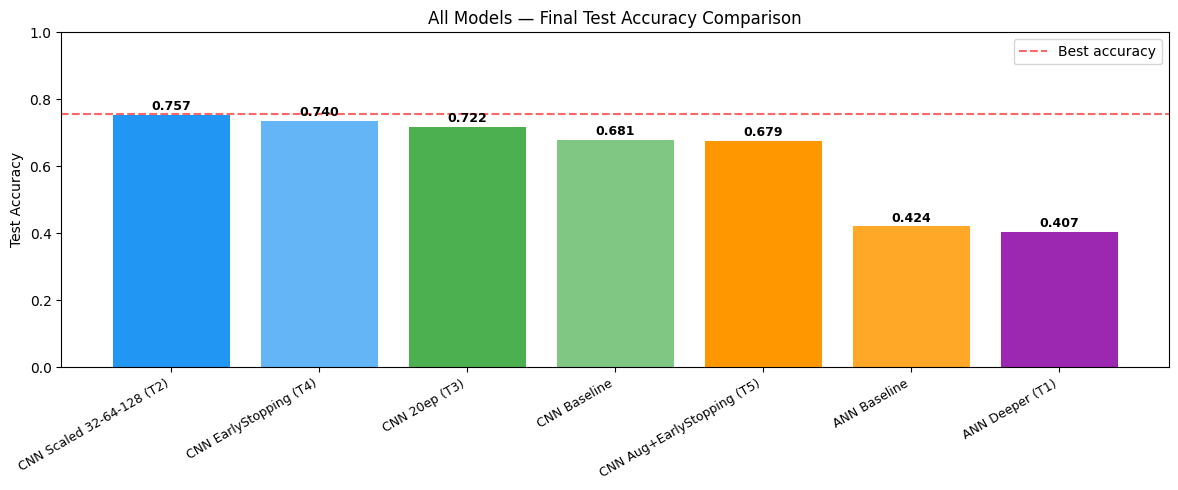

In [24]:
# Task 5: Full augmented CNN — 20 epochs with EarlyStopping
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

aug_full_model = models.Sequential([
    data_aug,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name="Augmented_CNN_Full")

aug_full_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

aug_full_model.summary()

early_stop_aug = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

aug_full_history = aug_full_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug],
    verbose=1
)

_, aug_full_acc = aug_full_model.evaluate(x_test_norm, y_test)
print(f"\nAugmented Full CNN Test Accuracy: {aug_full_acc:.4f}")

# ── Final complete comparison across all 5 tasks ──
print("\n" + "="*55)
print("FINAL MODEL COMPARISON — All Tasks")
print("="*55)
final_comparison = pd.DataFrame({
    "Model":         ["ANN Baseline", "ANN Deeper (T1)", "CNN Baseline",
                      "CNN Scaled 32-64-128 (T2)", "CNN 20ep (T3)",
                      "CNN EarlyStopping (T4)", "CNN Aug+EarlyStopping (T5)"],
    "Test Accuracy": [round(ann_test_acc,4), round(ann_deep_acc,4), round(cnn_test_acc,4),
                      round(cnn_scaled_acc,4), round(cnn_20ep_acc,4),
                      round(cnn_early_acc,4), round(aug_full_acc,4)]
})
final_comparison = final_comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
print(final_comparison.to_string(index=False))

# Bar chart
plt.figure(figsize=(12, 5))
colors = ['#2196F3','#64B5F6','#4CAF50','#81C784','#FF9800','#FFA726','#9C27B0']
bars = plt.bar(final_comparison["Model"], final_comparison["Test Accuracy"], color=colors, edgecolor='white', linewidth=0.7)
plt.axhline(y=final_comparison["Test Accuracy"].max(), color='red', linestyle='--', alpha=0.6, label='Best accuracy')
for bar, val in zip(bars, final_comparison["Test Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title("All Models — Final Test Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.ylim(0, 1)
plt.legend(); plt.tight_layout(); plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**